In [1]:
# Jupyter Notebook Auto Reload
%load_ext autoreload
%autoreload 2

# Jupyter Notebook inline
%matplotlib inline

%config InlineBackend.figure_format = 'retina'

In [24]:
import sys
sys.path.append('..')

import os
import scienceplots
import time
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.lines import Line2D

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets.fobss import FOBSS
from datasets.utils import *
from models.battery import LiBPINN
from config import settings
from utils import *



# set the plotting style
plt.style.use(['science', 'ieee'])


plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    # "lines.linewidth": 1.5
})

# set font family
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'Noto Sans CJK SC', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False   


pd.set_option('display.max_columns', None)

# fix the random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# device = torch.device('cpu')
pinn = LiBPINN(**settings.model.model_dump())
checkpoint =  torch.load('../checkpoints/fobss/pretrain-model-fobss-best.pt', weights_only=True)
pinn.load_state_dict(checkpoint['model_state'])

<All keys matched successfully>

In [ ]:
from models.detector import LiSAD
from models.ekf import *
from models.ukf import *

from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from pyod.models.auto_encoder import AutoEncoder
from pyod.models.deep_svdd import DeepSVDD
from pyod.models.gmm import GMM
from pyod.models.pca import PCA
from pyod.models.vae import VAE

from TSB_AD.models.TranAD import TranAD
from TSB_AD.models.OmniAnomaly import OmniAnomaly
from TSB_AD.models.LSTMAD import LSTMAD
from TSB_AD.models.USAD import USAD

# methods comparison
methods = {
    "EKF-NIS": MultiCell_EKF_NIS_Detector(dt=10.0),
    "EKF-WLGLR": MultiCell_EKF_WLGLR_Detector(dt=10.0, window=10),
    "UKF-NIS": MultiCell_UKF_NIS_Detector(dt=10.0, ),
    "UKF-WLGLR": MultiCell_UKF_WLGLR_Detector(dt=10.0, window=10),
    
    'IForest': IForest(),
    'LOF': LOF(),
    'PCA': PCA(),
    'OCSVM': OCSVM(),
    'GMM': GMM(n_components=3),

    'AE': AutoEncoder(verbose=0),
    'VAE': VAE(),
    'DeepSVDD': DeepSVDD(n_features=23, verbose=-1),
    'LSTMAD': LSTMAD(window_size=100, feats=23),
    'USAD': USAD(win_size=100, feats=23),
    'TranAD': TranAD(win_size=100, feats=23),
    'OmniAnomaly': OmniAnomaly(win_size=100, feats=23),
    
    'LiSAD-GMM': LiSAD(pinn=pinn, detector=GMM(n_components=3), window_length=100, n_cell=11, use_mean=True),
}

# load the training data
train_X =  pd.read_csv('../data/FOBSS/train/D10C25-slave@0-interval@10.0s.csv').drop(columns=['Label'],axis=1).values     

# train and fit the models
for name in methods.keys():
    print(f"Training {name}...")
    methods[name].fit(train_X)

----- Using GPU 0 -----
self.device:  cuda:0
----- Using GPU 0 -----
----- Using GPU 0 -----
----- Using GPU 0 -----
Training EKF-NIS...
Training EKF-WLGLR...
Training UKF-NIS...
Training UKF-WLGLR...
Training IForest...
Training LOF...
Training PCA...
Training OCSVM...
Training GMM...
Training AE...
Training VAE...


Training: 100%|██████████| 30/30 [00:19<00:00,  1.51it/s]


Training DeepSVDD...
Training LSTMAD...


Validation Epoch [27/50]: 100%|██████████| 26/26 [00:00<00:00, 962.91it/s, avg_loss=0.111, loss=0.0853]


EarlyStopping counter: 1 out of 3


...

EarlyStopping counter: 1 out of 3


Validation Epoch [6/50]: 100%|██████████| 26/26 [00:00<00:00, 928.21it/s, avg_loss_val=0.998, loss=0.515]


EarlyStopping counter: 2 out of 3


Validation Epoch [7/50]: 100%|██████████| 26/26 [00:00<00:00, 793.19it/s, avg_loss_val=0.998, loss=0.515]


EarlyStopping counter: 3 out of 3
   Early stopping<<<
Training LiSAD-GMM...


In [ ]:
from eval.metrics import evaluate_scores
from sklearn.preprocessing import MinMaxScaler

def smooth_scores(scores, window_size=10):
    """Smooth the anomaly scores using a moving average filter."""
    smoothed_scores = np.convolve(scores, np.ones(window_size)/window_size, mode='same')
    return smoothed_scores

def run_evaluation(test_X, test_labels, methods):
    scaler = MinMaxScaler()
    results = {}
    for name in methods.keys():
        print(f"Evaluating {name}...")
        t0 = time.time()
        test_scores = methods[name].decision_function(test_X)
        t1 = time.time()
        # print(f"Time taken for {name}: {t1 - t0:.4f} seconds")
       
        # smooth the scores
        test_scores = smooth_scores(test_scores, window_size=3)

        scores_scaled = scaler.fit_transform(test_scores.reshape(-1, 1)).flatten()
        results[name] = evaluate_scores(test_labels, scores_scaled)
        results[name]['scores'] = scores_scaled
        results[name]['time'] = t1 - t0
        # print(f"Results for {name}: {results[name]}")

    return results

def results_to_excel(results, test_labels, filename='results.xlsx'):
    """
    Save experimental results to an Excel file.
    - Sheet 1: Main experimental results (metrics).
    - Sheet 2: Scores for each method and test_labels.
    """
    # 1. Main experimental results
    df_metrics = pd.DataFrame(results).T.drop(columns=['scores'], errors='ignore')
    df_metrics.reset_index(inplace=True)
    df_metrics.rename(columns={'index': 'Method'}, inplace=True)
    
    # 2. Scores and labels
    scores_dict = {'test_labels': test_labels}
    for name, res in results.items():
        if 'scores' in res:
            scores_dict[name] = res['scores']
    df_scores = pd.DataFrame(scores_dict)


    # directory check
    if not os.path.exists(os.path.dirname(filename)):
        os.makedirs(os.path.dirname(filename))

    # Write to Excel
    with pd.ExcelWriter(filename) as writer:
        df_metrics.to_excel(writer, sheet_name='Main Results', index=False)
        df_scores.to_excel(writer, sheet_name='Detection Scores', index=False)
    print(f"Results successfully saved to {filename}")



In [ ]:
data_dir = '../data/FOBSS/test/'
test_files = [f for f in os.listdir(data_dir) if f.endswith('.csv') and '-N-' not in f]
print("Test files to be processed:", test_files)
for test_file in test_files:    
    print(f"Processing file: {test_file}")
    test_data = pd.read_csv(os.path.join(data_dir, test_file))
    test_labels = test_data['Label'].values
    test_X = test_data.drop(columns=['Label'], axis=1).values
    
    results = run_evaluation(test_X, test_labels, methods)

    # Save results to Excel
    result_filename = f'../results/FOBSS/{test_file.replace(".csv", "_results.xlsx")}'
    results_to_excel(results, test_labels, filename=result_filename)

In [11]:
results_dir = '../results/FOBSS/'
df_results_info = pd.DataFrame({'filename':os.listdir(results_dir)})
df_results_info['conditions'] = df_results_info['filename'].apply(lambda x: x.split('-')[0])
df_results_info['attack_type'] = df_results_info['filename'].apply(lambda x: x.split('-')[1])
df_results_info['slave'] = df_results_info['filename'].apply(lambda x: x.split('-')[2])
df_results_info

,filename,conditions,attack_type,slave
0,D10C25-A3-slave@3-interval@10.0s_results.xlsx,D10C25,A3,slave@3
1,D10C25-A7-slave@0-interval@10.0s_results.xlsx,D10C25,A7,slave@0
2,D10C25-A4-slave@0-interval@10.0s_results.xlsx,D10C25,A4,slave@0
3,D0C10-A1-slave@0-interval@10.0s_results.xlsx,D0C10,A1,slave@0
4,D0C10-A2-slave@2-interval@10.0s_results.xlsx,D0C10,A2,slave@2
5,D10C10-A2-slave@1-interval@10.0s_results.xlsx,D10C10,A2,slave@1
6,D10C25-A3-slave@1-interval@10.0s_results.xlsx,D10C25,A3,slave@1
7,D10C25-A2-slave@3-interval@10.0s_results.xlsx,D10C25,A2,slave@3
8,D10C10-A2-slave@3-interval@10.0s_results.xlsx,D10C10,A2,slave@3
9,D10C25-A6-slave@0-interval@10.0s_results.xlsx,D10C25,A6,slave@0


In [12]:
def aggregate_results(results_dir, result_files):
    all_results = []
    for file in result_files:
        if file.endswith('_results.xlsx'):
            df = pd.read_excel(os.path.join(results_dir, file), sheet_name='Main Results')
            df['Test File'] = file
            all_results.append(df)
    df_aggregated = pd.concat(all_results, ignore_index=True)
    return df_aggregated

results_dir = '../results/FOBSS/'
selected_files = df_results_info[(df_results_info['conditions'].isin(['D10C25','D0C10'])) & 
                                 (df_results_info['attack_type'].isin(['A1','A2','A3','A4', 'A5', 'A6', 'A7']))]['filename'].values
df_aggregated_results = aggregate_results(results_dir, result_files=selected_files)

df_aggregated_stats = df_aggregated_results.groupby('Method', as_index=False).agg({'AUC-ROC': ['mean','std'], 'AUC-PR': ['mean','std'], 'F1': ['mean','std'], 'FPR@95TPR': ['mean','std'], 'TTFD': ['mean','std'], 'NWDD': ['mean','std'], 'TAS': ['mean','std']})

method_order = list(methods.keys())

# reordering
df_aggregated_stats = df_aggregated_stats.set_index('Method').loc[method_order].reset_index()
df_aggregated_stats.round(3)

Method AUC-ROC        AUC-PR            F1        FPR@95TPR         \
                   mean    std   mean    std   mean    std      mean    std   
0       EKF-NIS   0.539  0.128  0.684  0.309  0.654  0.326     0.860  0.211   
1     EKF-WLGLR   0.602  0.170  0.691  0.317  0.664  0.321     0.799  0.284   
2       UKF-NIS   0.541  0.127  0.686  0.308  0.654  0.326     0.860  0.212   
3     UKF-WLGLR   0.604  0.173  0.691  0.317  0.664  0.321     0.794  0.283   
4       IForest   0.338  0.182  0.622  0.345  0.592  0.396     0.957  0.088   
5           LOF   0.423  0.176  0.624  0.312  0.627  0.341     0.932  0.175   
6           PCA   0.344  0.266  0.600  0.301  0.613  0.354     0.905  0.185   
7         OCSVM   0.237  0.317  0.576  0.319  0.614  0.368     0.894  0.231   
8           GMM   0.298  0.248  0.602  0.298  0.626  0.366     0.945  0.179   
9            AE   0.591  0.235  0.785  0.256  0.748  0.261     0.790  0.340   
10          VAE   0.316  0.263  0.588  0.298  0.603  0.369     0.911  0.170   
11     DeepSVDD   0.373  0.264  0.620  0.286  0.647  0.305     0.892  0.213   
12       LSTMAD   0.576  0.241  0.802  0.201  0.796  0.197     0.812  0.368   
13         USAD   0.513  0.345  0.690  0.235  0.697  0.243     0.825  0.299   
14       TranAD   0.492  0.298  0.678  0.285  0.682  0.261     0.929  0.135   
15  OmniAnomaly   0.433  0.291  0.710  0.217  0.736  0.222     0.819  0.340   
16    LiSAD-GMM   0.848  0.131  0.938  0.069  0.903  0.103     0.456  0.386   

      TTFD           NWDD           TAS         
      mean     std   mean    std   mean    std  
0   10.208  15.160  0.025  0.112 -0.044  0.048  
1    8.875  15.521  0.025  0.112 -0.062  0.086  
2   11.333  15.429  0.026  0.114 -0.045  0.050  
3    9.833  15.810  0.026  0.114 -0.063  0.086  
4      inf     NaN  0.292  0.464  0.010  0.102  
5      inf     NaN  0.196  0.370 -0.012  0.047  
6      inf     NaN  0.160  0.316  0.069  0.155  
7      inf     NaN  0.246  0.416 -0.029  0.062  
8      inf     NaN  0.218  0.403  0.013  0.083  
9      inf     NaN  0.083  0.237  0.009  0.112  
10     inf     NaN  0.256  0.422  0.094  0.168  
11     inf     NaN  0.103  0.239  0.102  0.155  
12   3.875   8.013  0.002  0.003  0.035  0.064  
13   3.333   9.059  0.014  0.058  0.097  0.128  
14   0.167   0.637  0.003  0.008  0.072  0.122  
15     inf     NaN  0.043  0.204  0.102  0.141  
16  11.750  12.480  0.003  0.004  0.092  0.141

In [ ]:
# load test data
data_name = 'D10C25-A2-slave@0-interval@10.0s'
test_X = pd.read_csv(f'../data/FOBSS/test/{data_name}.csv')
test_labels = test_X['Label'].values
test_X = test_X.drop(columns=['Label'],axis=1).values

# run evaluation
results = run_evaluation(test_X, test_labels, methods)

# save results to excel
results_to_excel(results, test_labels, filename=f'../eval_results/{data_name}.xlsx')

# --- IGNORE ---
df = pd.DataFrame(results).T
df.drop(columns=['_threshold','scores'], axis=1)

Evaluating EKF-NIS...
Evaluating EKF-WLGLR...
Evaluating UKF-NIS...
Evaluating UKF-WLGLR...
Evaluating IForest...
Evaluating LOF...
Evaluating PCA...
Evaluating OCSVM...
Evaluating GMM...
Evaluating AE...
Evaluating VAE...
Evaluating DeepSVDD...
Evaluating LSTMAD...


Testing: : 100%|██████████| 8/8 [00:00<00:00, 1186.72it/s]


Evaluating USAD...


100%|██████████| 8/8 [00:00<00:00, 1401.31it/s]


Evaluating TranAD...


100%|██████████| 8/8 [00:00<00:00, 526.65it/s]


Evaluating OmniAnomaly...


100%|██████████| 8/8 [00:00<00:00, 1490.18it/s]

Evaluating LiSAD-GMM...
Results successfully saved to ../eval_results/D10C25-A2-slave@0-interval@10.0s.xlsx


,AUC-ROC,AUC-PR,F1,FPR@95TPR,TTFD,NWDD,TAS,time
EKF-NIS,0.546384,0.816659,0.796974,0.92823,21,0.000891,-0.022739,0.718392
EKF-WLGLR,0.544163,0.816011,0.794451,0.92823,25,0.001145,-0.017449,0.76273
UKF-NIS,0.551374,0.818195,0.796974,0.92823,21,0.000891,-0.022557,2.164628
UKF-WLGLR,0.548701,0.81738,0.795712,0.923445,25,0.001145,-0.017046,2.263756
IForest,0.3955,0.772781,0.745592,0.995215,0,0.000032,-0.072768,0.002803
LOF,0.406029,0.708852,0.80454,0.923445,21,0.000891,0.014568,0.008049
PCA,0.04118,0.59474,0.737705,1.0,0,0.000032,0.066424,0.00022
OCSVM,0.295734,0.780903,0.737705,0.995215,0,0.000032,-0.055367,0.21689
GMM,0.342549,0.706097,0.765448,0.990431,0,0.000032,0.066613,0.000417
AE,0.507062,0.834196,0.784363,0.995215,0,0.000032,0.075874,0.021132


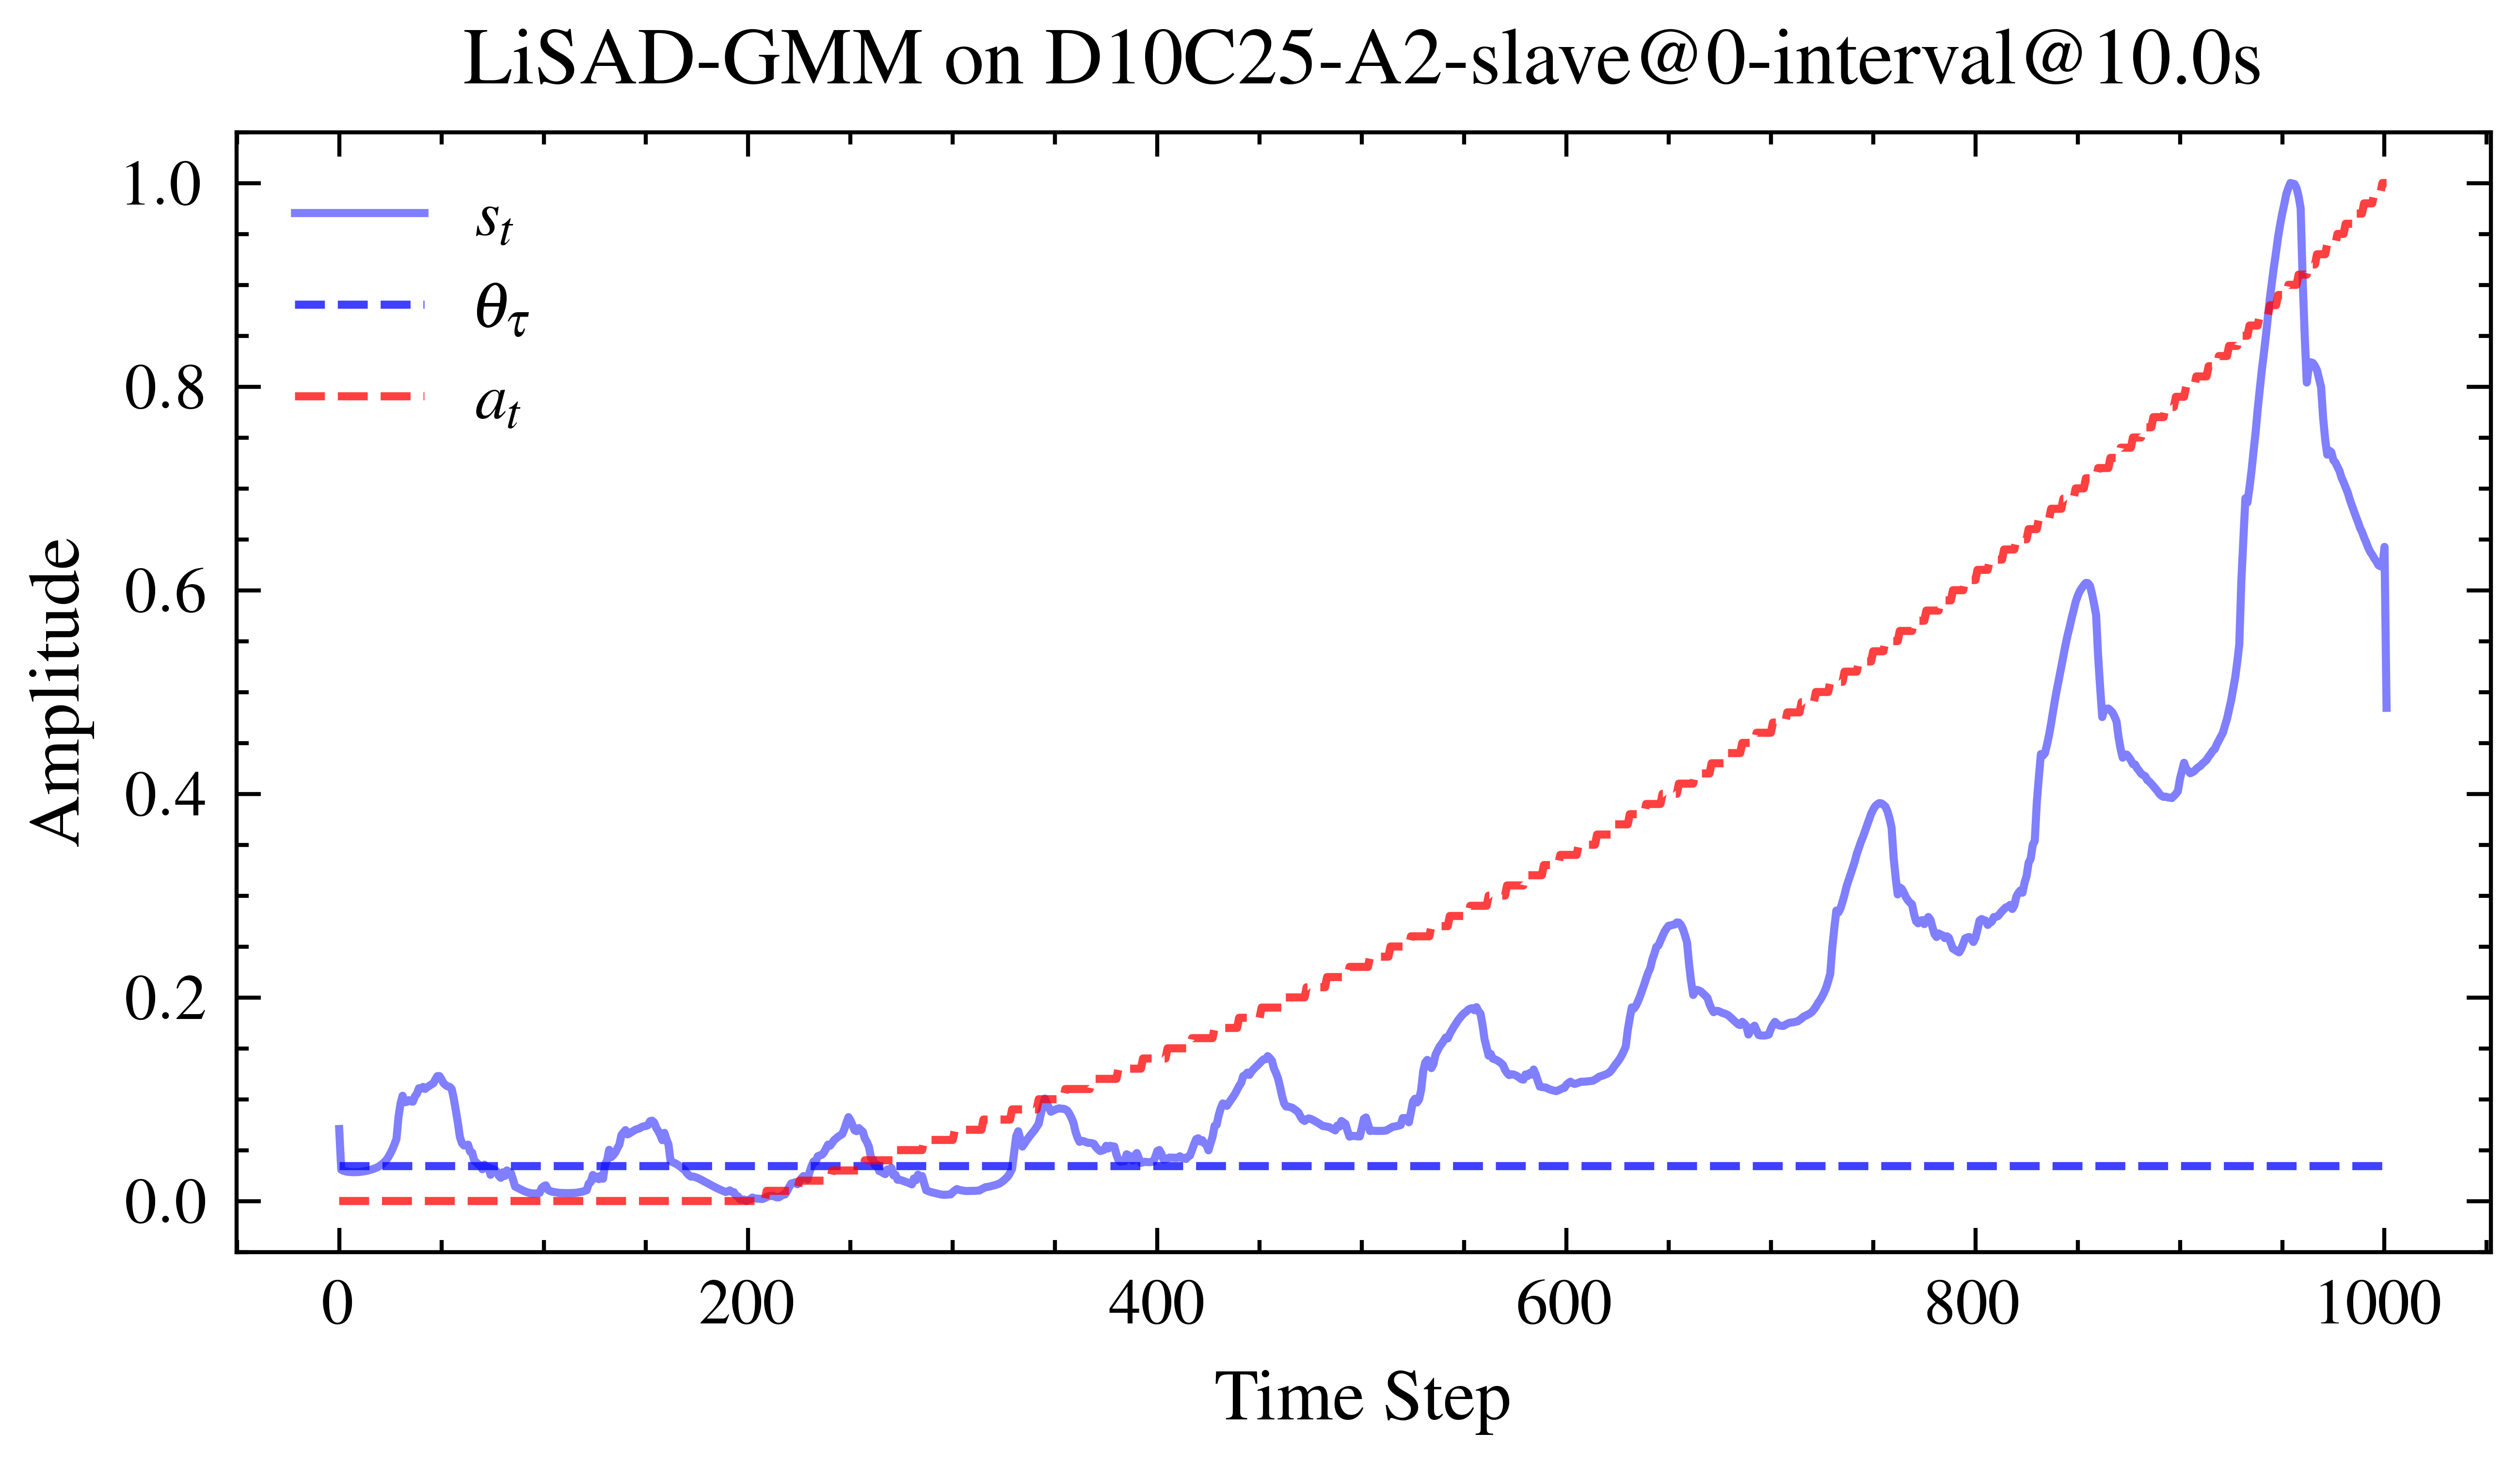

In [55]:
method_name = 'LiSAD-GMM'
fig, ax = plt.subplots(figsize=(5,2.5))
ax.plot(results[method_name]['scores'], label='$s_t$', color='blue', alpha=0.5)
threshold = results[method_name]['_threshold']
ax.hlines(threshold, xmin=0, xmax=len(test_labels), colors='blue', alpha=0.75, linestyles='--', label='$\\theta_{\\tau}$')

ax.plot(test_labels, label='$a_t$', color='red', alpha=0.75)

ax.set_xlabel('Time Step')
ax.set_ylabel('Amplitude')
ax.set_title(f'{method_name} on {data_name}')
ax.legend(loc='upper left')
plt.show()

In [56]:
def select_topk_methods(df_results, metrics, direction='descending', k=5):
    """
    Select top-k methods based on specified metrics.
    Args:
        df_results (pd.DataFrame): DataFrame containing results with methods as index.
        metrics (list): List of metric names to consider for ranking.
        direction (str): 'ascending' or 'descending' for ranking order.
        k (int): Number of top methods to select.   
    Returns:
        list: List of top-k method names.
    """
    if direction == 'descending':
        df_ranked = df_results.sort_values(by=metrics, ascending=False)
    else:
        df_ranked = df_results.sort_values(by=metrics, ascending=True)
    topk_methods = df_ranked.head(k).index.tolist()
   
    return topk_methods

topk_methods = select_topk_methods(df, metrics=['AUC-ROC', 'F1'], direction='descending', k=5)
topk_methods

['LiSAD-GMM', 'LSTMAD', 'UKF-NIS', 'UKF-WLGLR', 'EKF-NIS']

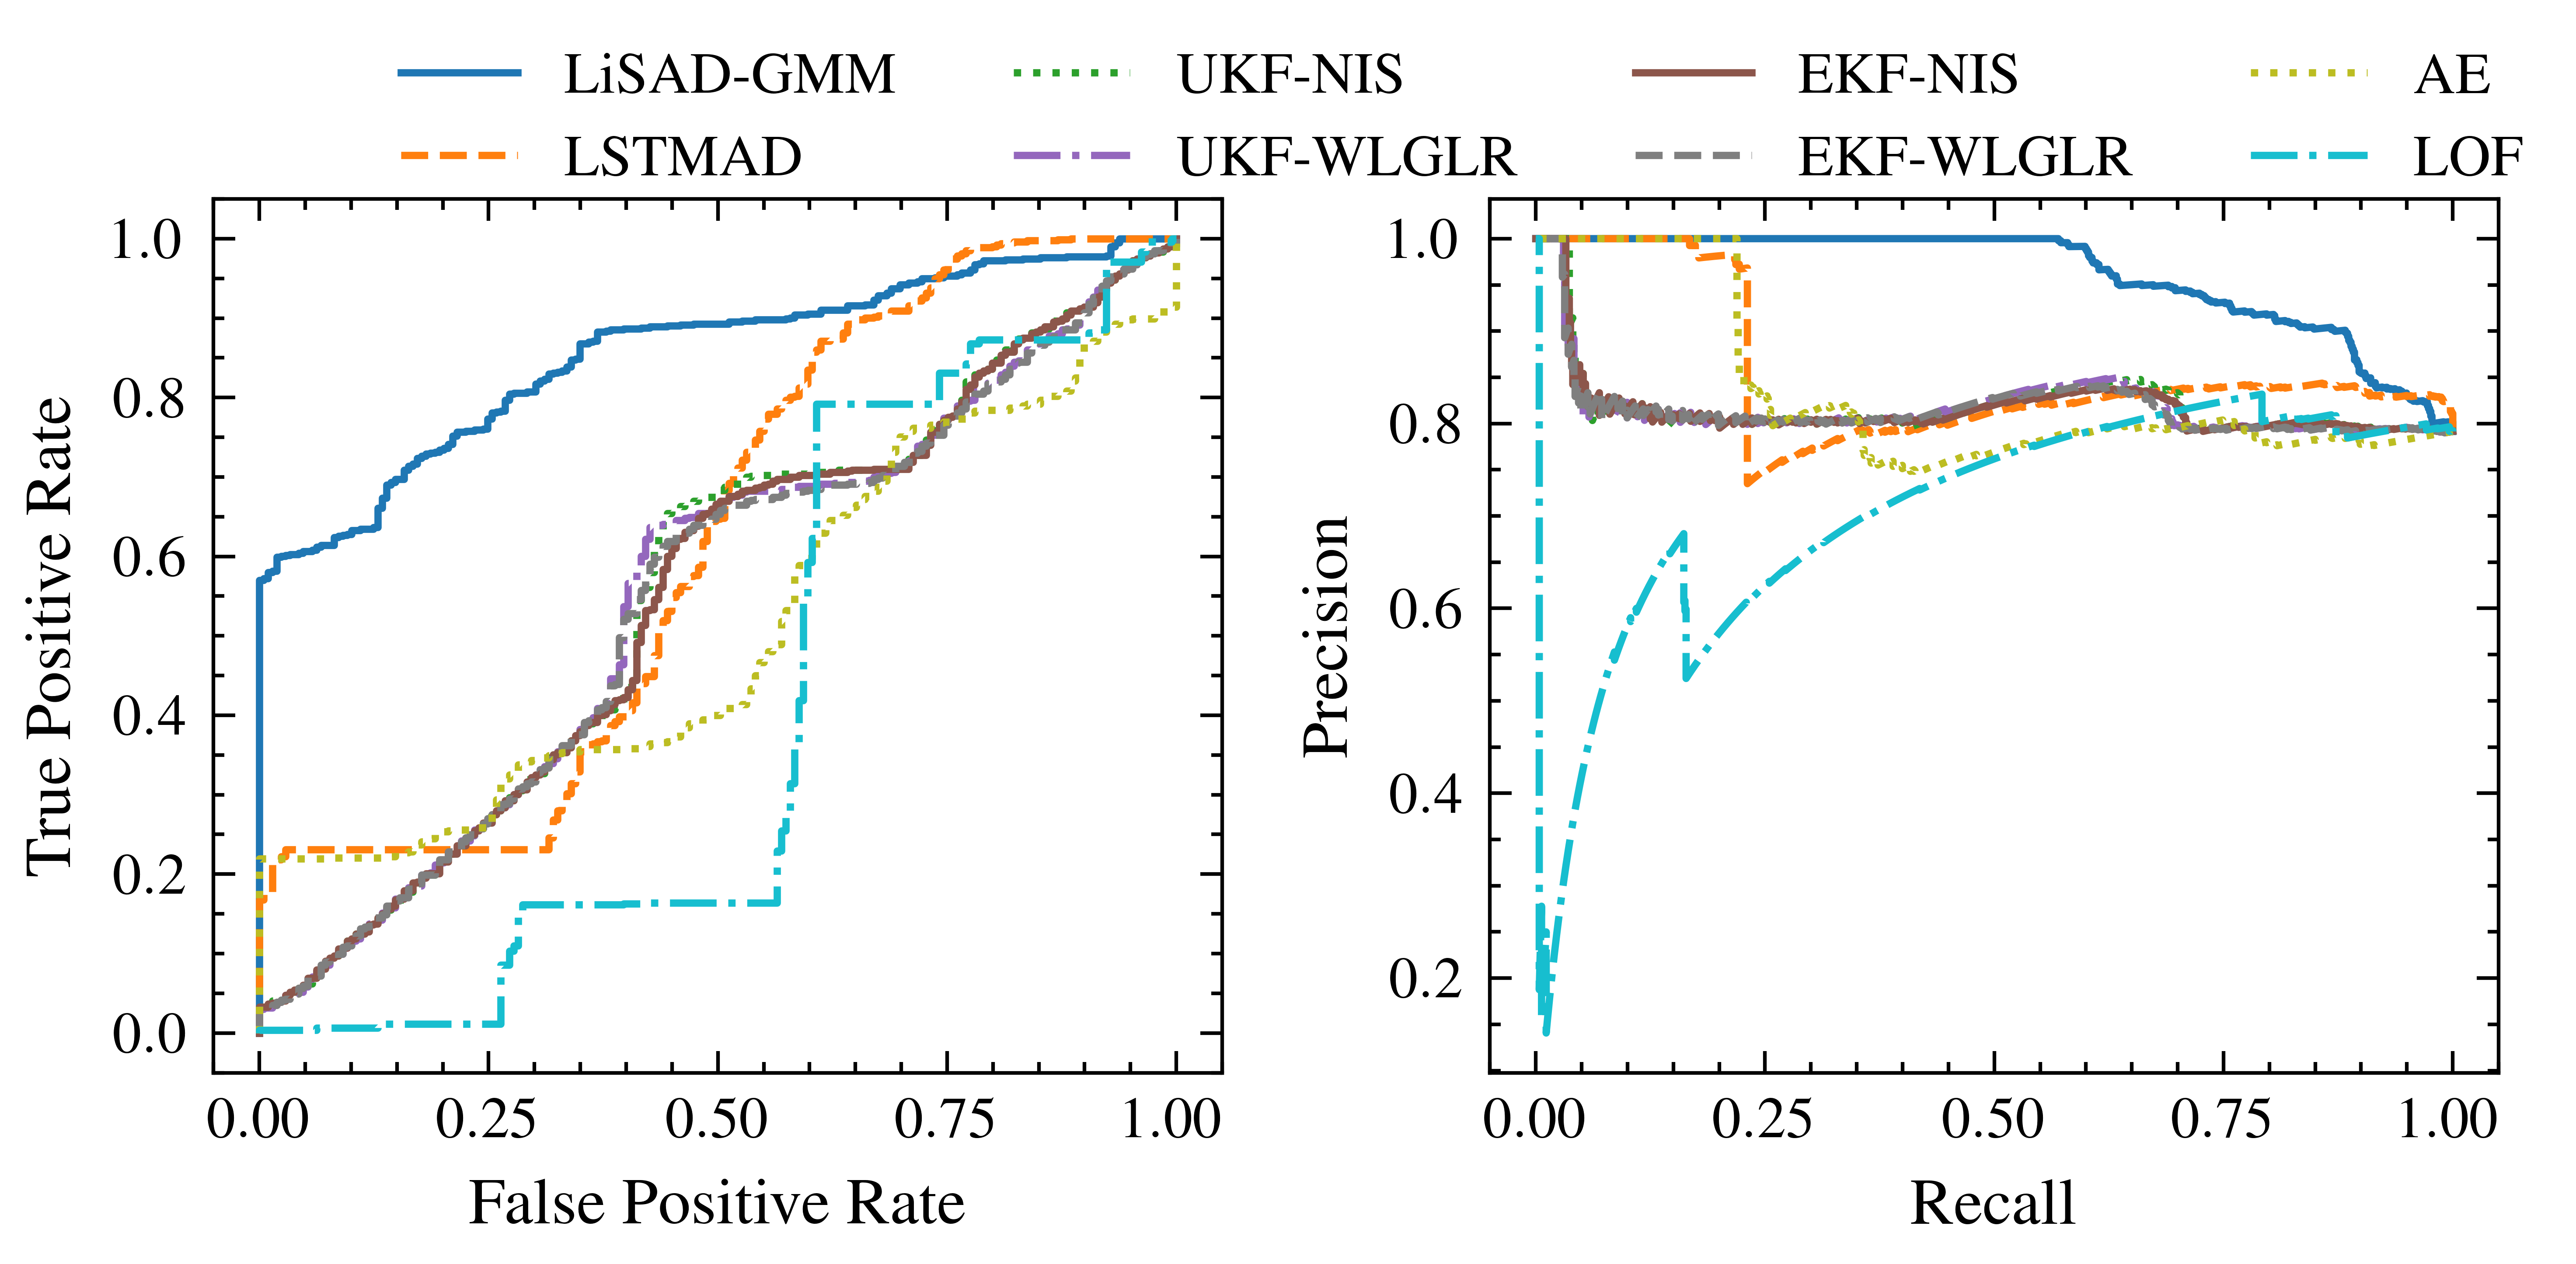

In [57]:
def plot_auc_roc_pr(results, method_names, test_labels):
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    
    test_labels_binary = (test_labels > 0).astype(int)

    fig, axs = plt.subplots(1, 2, figsize=(5, 2.5))

    colors = plt.cm.get_cmap('tab10', len(method_names))

    for i, method_name in enumerate(method_names):
        scores = results[method_name]['scores']
    
        # AUC-ROC
        fpr, tpr, _ = roc_curve(test_labels_binary, scores)
        axs[0].plot(fpr, tpr, label=f'{method_name}', color=colors(i))
        axs[0].set_xlabel('False Positive Rate')
        axs[0].set_ylabel('True Positive Rate')
        # axs[0].set_title('ROC Curve')

        # AUC-PR
        precision, recall, _ = precision_recall_curve(test_labels_binary, scores)
        axs[1].plot(recall, precision, label=f'{method_name}', color=colors(i))
        axs[1].set_xlabel('Recall')
        axs[1].set_ylabel('Precision')
        # axs[1].set_title('Precision-Recall Curve')

    
    # Unify the legend to the top of the diagram
    handles, labels = axs[0].get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper right', ncol=4)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

topk_methods = select_topk_methods(df, metrics=['AUC-ROC', 'AUC-PR'], direction='descending', k=8)
plot_auc_roc_pr(results, method_names=topk_methods, test_labels=test_labels)

In [58]:
def plot_detection_scores(test_labels, method_names, axs):
    for ax, method_name in zip(axs.flatten(), method_names):

        ax.plot(results[method_name]['scores'], label='Normalized Detection Score $s(k)$', color='#4F7DD8', alpha=0.85)
        ax.hlines(results[method_name]['_threshold']+0.08, xmin=0, xmax=len(test_labels), colors="#2B2186", alpha=0.85, linestyles='-.', label=' Threshold ($\\theta_{\\tau}$)')

        ax.plot(test_labels, label='Normalized Attack Intensity $a(k)$', color='#BA4F54', alpha=0.85)

        ax.set_xlabel('$k$')
        ax.set_ylabel('Value')
        ax.set_title(f'{method_name}')
        ax.grid(True, linestyle='--', alpha=0.5)
    
    # Create a single legend for all subplots
    handles, labels = axs[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', ncol=3)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
 

fig, axs = plt.subplots(4,4, figsize=(7.4, 7), sharex=False, sharey=False)
selected_methods = select_topk_methods(df, metrics=['AUC-ROC', 'TAS'], direction='descending', k=16)
plot_detection_scores(test_labels, selected_methods, axs)
# plt.savefig('../figures/detection_scores_fobss.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [130]:
df_X = pd.read_csv(f'../data/FOBSS/test/{data_name}.csv')
print(df_X.columns)
df_I = df_X[['I']]
df_V = df_X[[col for col in df_X.columns if col.startswith('V')]]
df_T = df_X[[col for col in df_X.columns if col.startswith('T')]]
df_Label = df_X[['Label']]

# ---- merge into one figure (top: I/V/T, bottom: 4x4 detection scores) ----
fig = plt.figure(figsize=(7.4, 7))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 6])

# Top row: raw signals
sg_top = gs[0].subgridspec(1, 3, wspace=0.3)
axs_top = [fig.add_subplot(sg_top[0, i]) for i in range(3)]

axs_top[0].plot(df_I, color="#49504C")
axs_top[0].set_ylabel('$I$(A)')
axs_top[0].set_xlabel('$k$')
axs_top[0].set_title('(a) Module current')

axs_top[1].plot(df_V)
axs_top[1].set_ylabel('$V$(V)')
axs_top[1].set_xlabel('$k$')
axs_top[1].set_title('(b) Cell voltages')

axs_top[2].plot(df_T)
axs_top[2].set_ylabel('$T$(°C)')
axs_top[2].set_xlabel('$k$')
axs_top[2].set_title('(c) Cell temperatures')

# attack intensity shading on V
y_min, y_max = axs_top[1].get_ylim()
for i in range(len(df_Label) - 1):
    start = df_I.index[i]
    end = df_I.index[i + 1]
    intensity = df_Label["Label"].iloc[i]
    if intensity > 0:
        alpha = intensity * 0.15  # scale alpha to 0-0.5 for visibility
        axs_top[1].fill_between([start, end], y_min, y_max, color="#BA4F54", alpha=alpha)

# Bottom: 4x4 methods
sg_bot = gs[1].subgridspec(4, 4, wspace=0.4, hspace=0.7)
axs_grid = [[fig.add_subplot(sg_bot[i, j]) for j in range(4)] for i in range(4)]
axs_flat = [ax for row in axs_grid for ax in row]

selected_methods = select_topk_methods(df, metrics=['AUC-ROC', 'TAS'], direction='descending', k=16)
for ax, method_name in zip(axs_flat, selected_methods):
    ax.plot(
        results[method_name]['scores'],
        label='Normalized detection score $s(k)$',
        color='#4F7DD8',
        alpha=0.85,
    )
    # ax.hlines(
    #     results[method_name]['_threshold'] + 0.08,
    #     xmin=0,
    #     xmax=len(test_labels),
    #     colors="#2B2186",
    #     alpha=0.85,
    #     linestyles='-.',
    #     label=' Threshold $\\theta_{\\tau}$',
    # )

    y_min, y_max = ax.get_ylim()
    for i in range(len(df_Label) - 1):
        start = df_I.index[i]
        end = df_I.index[i + 1]
        intensity = df_Label["Label"].iloc[i]
        if intensity > 0:
            alpha = intensity * 0.15  # scale alpha to 0-0.5 for visibility
            ax.fill_between([start, end], y_min, y_max, color="#BA4F54", alpha=alpha)

    ax.plot(test_labels, label='Normalized attack intensity $a(k)$', color='#BA4F54', alpha=0.85)

    ax.set_xlabel('$k$')
    ax.set_ylabel('$f(k)$')
    n = selected_methods.index(method_name) + 4
    # n to alphabet: 1->a, 2->b, ...
    n = chr(96 + n)
    ax.set_title(f'({n}) {method_name}')
    # ax.grid(True, linestyle='--', alpha=0.5)

# single legend for the whole figure (from the first subplot)
handles, labels = axs_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.7, 0.995))

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../figures/detection_scores_fobss.pdf', dpi=300, bbox_inches='tight')
plt.show()


Index(['I', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11',
       'Label'],
      dtype='object')
